# Load

In [ ]:
import pandas as pd
data = pd.read_csv("dblp-v10.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   abstract    827533 non-null   object
 1   authors     999998 non-null   object
 2   n_citation  1000000 non-null  int64 
 3   references  875583 non-null   object
 4   title       1000000 non-null  object
 5   venue       822245 non-null   object
 6   year        1000000 non-null  int64 
 7   id          1000000 non-null  object
dtypes: int64(2), object(6)
memory usage: 61.0+ MB


# Publications in Year Ranges

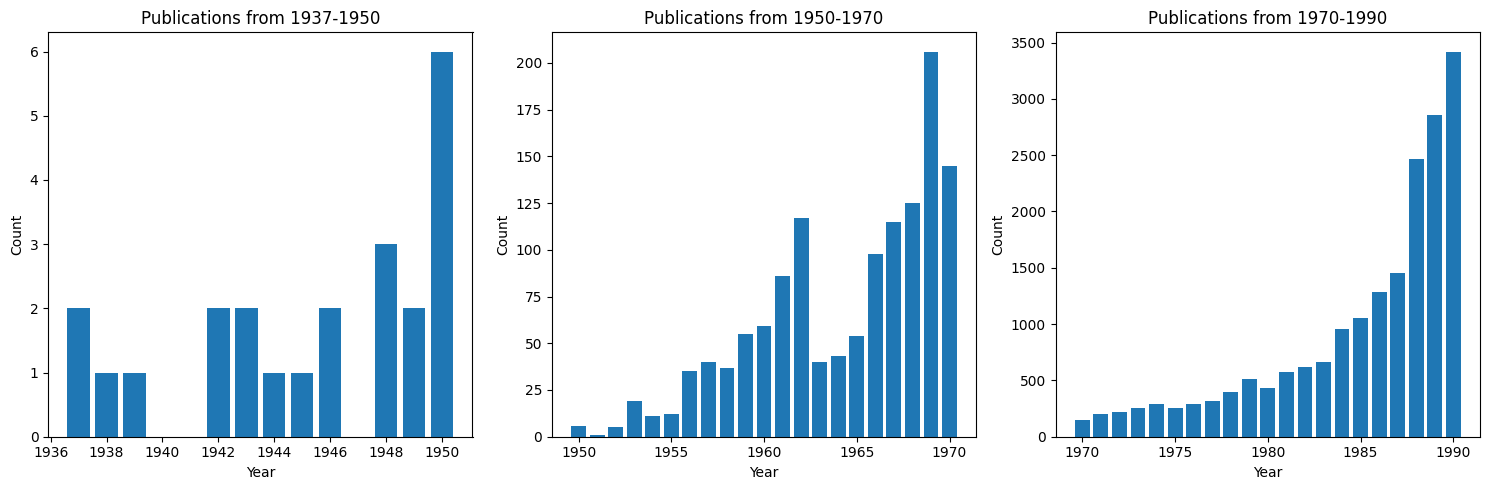

In [ ]:
import matplotlib.pyplot as plt

# Define year ranges
ranges = [(1937, 1950), (1950, 1970), (1970, 1990)]

# Plot bar charts for each range
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, (start, end) in enumerate(ranges):
    subset = data[(data['year'] >= start) & (data['year'] <= end)]
    year_counts = subset['year'].value_counts().sort_index()
    axes[i].bar(year_counts.index, year_counts.values)
    axes[i].set_title(f'Publications from {start}-{end}')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

# \# of References Over the Years

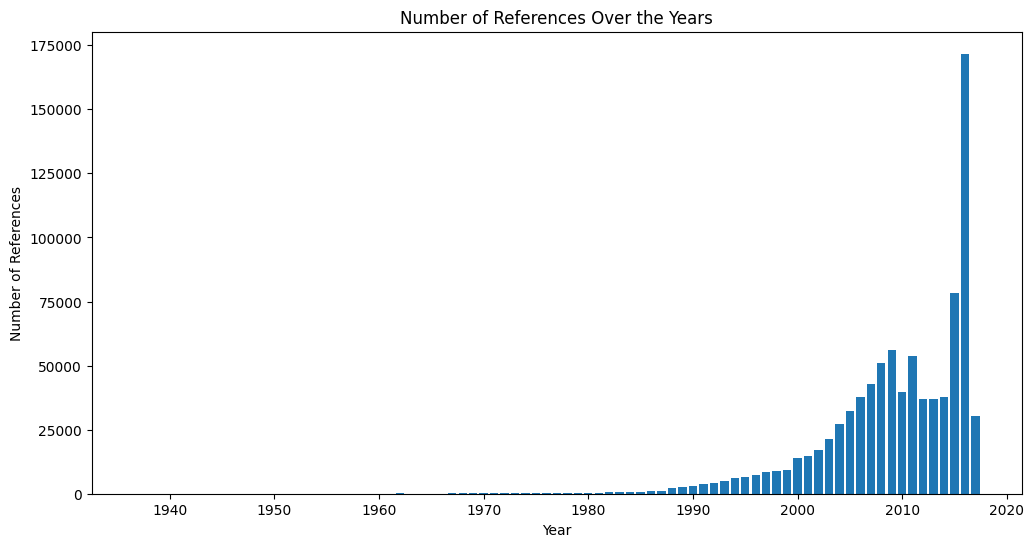

In [ ]:
# Count references per year
yearly_references = data.dropna(subset='references').groupby('year').size()

# Plot
plt.figure(figsize=(12, 6))
plt.bar(yearly_references.index, yearly_references.values)
plt.xlabel('Year')
plt.ylabel('Number of References')
plt.title('Number of References Over the Years')
plt.show()


# \# of Authors Over the Years

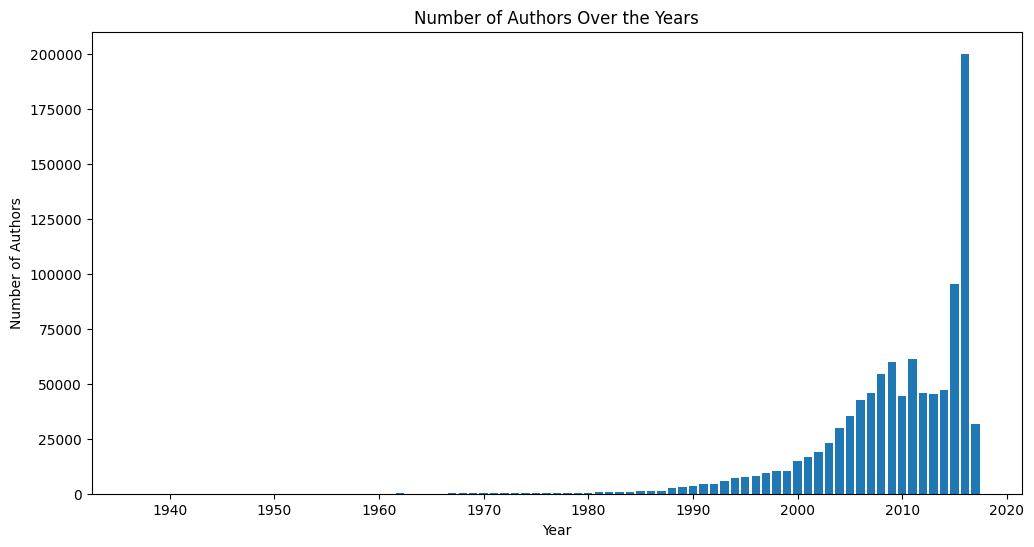

In [ ]:
# Count authors per year
yearly_authors = data.dropna(subset=['authors']).groupby('year').size()

# Plot
plt.figure(figsize=(12, 6))
plt.bar(yearly_authors.index, yearly_authors.values)
plt.xlabel('Year')
plt.ylabel('Number of Authors')
plt.title('Number of Authors Over the Years')
plt.show()


# Correlation Between Authors and References

In [ ]:
from scipy.stats import pearsonr, spearmanr

# Drop NaN values in both columns
corr_data = data.dropna(subset=['authors', 'references'])

# Convert authors and references to numerical counts
corr_data['num_authors'] = corr_data['authors'].apply(lambda x: len(x.split(',')))
corr_data['num_references'] = corr_data['references'].apply(lambda x: len(x.split(',')))

# Compute correlations
pearson_corr, _ = pearsonr(corr_data['num_authors'], corr_data['num_references'])
spearman_corr, _ = spearmanr(corr_data['num_authors'], corr_data['num_references'])

print(f'Pearson correlation: {pearson_corr}')
print(f'Spearman correlation: {spearman_corr}')


C:\Users\HAMAHANG\AppData\Local\Temp\ipykernel_16048\177334657.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  corr_data['num_authors'] = corr_data['authors'].apply(lambda x: len(x.split(',')))
C:\Users\HAMAHANG\AppData\Local\Temp\ipykernel_16048\177334657.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  corr_data['num_references'] = corr_data['references'].apply(lambda x: len(x.split(',')))


Pearson correlation: 0.05469801280482178
Spearman correlation: 0.08892459556500037


# Correlation Between Authors and citations

In [ ]:
# Drop NaN values in authors
corr_data = data.dropna(subset=['authors'])

# Convert authors to numerical counts
corr_data['num_authors'] = corr_data['authors'].apply(lambda x: len(x.split(',')))

# Compute correlations
pearson_corr, _ = pearsonr(corr_data['num_authors'], corr_data['n_citation'])
spearman_corr, _ = spearmanr(corr_data['num_authors'], corr_data['n_citation'])

print(f'Pearson correlation: {pearson_corr}')
print(f'Spearman correlation: {spearman_corr}')


C:\Users\HAMAHANG\AppData\Local\Temp\ipykernel_16048\2205378008.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  corr_data['num_authors'] = corr_data['authors'].apply(lambda x: len(x.split(',')))


Pearson correlation: -0.0028014430082150127
Spearman correlation: -0.01663360626731753


# title length over the years

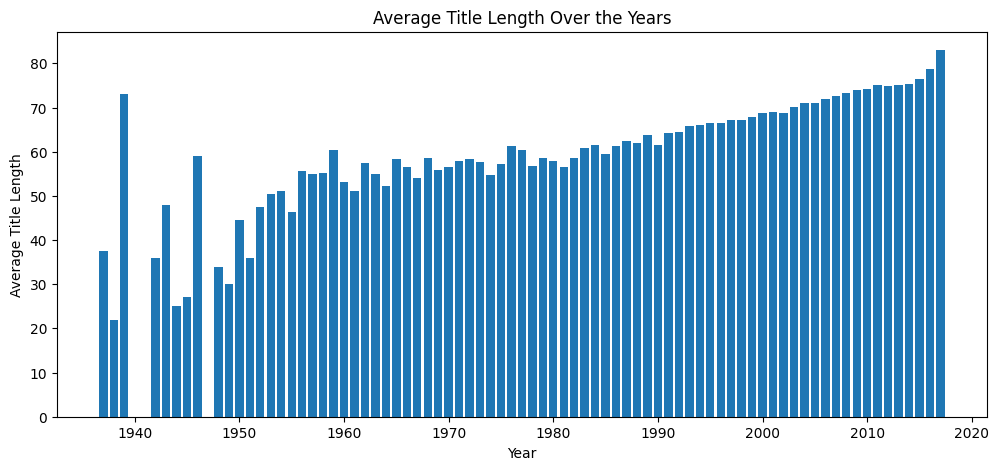

In [ ]:
# Compute title length
data['title_length'] = data['title'].apply(len)

# Group by year and compute average title length
title_length_by_year = data.groupby('year')['title_length'].mean()

# Plot
plt.figure(figsize=(12, 5))
plt.bar(title_length_by_year.index, title_length_by_year.values)
plt.xlabel('Year')
plt.ylabel('Average Title Length')
plt.title('Average Title Length Over the Years')
plt.show()


# wordcloud

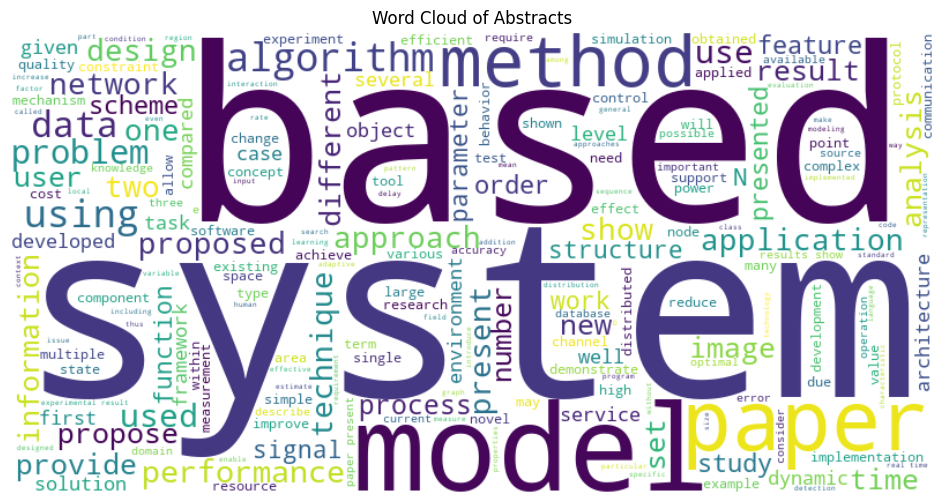

In [ ]:
from wordcloud import WordCloud

# Combine all abstracts
abstract_text = " ".join(data[:5000].dropna(subset=['abstract'])['abstract'])

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(abstract_text)

# Plot
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Abstracts')
plt.show()

# correlation between the title length and title length of referenced

In [ ]:
import pandas as pd
import numpy as np

Data = data[:50000].copy()

# Step 1: Ensure 'references' contains lists (handle NaN/None values)
Data['references'] = Data['references'].apply(lambda x: x if isinstance(x, str) else [])

# Step 2: Calculate the length of each paper's title
Data['title_length'] = Data['title'].apply(len)
# Step 3: Extract the titles of the referenced papers
Data['referenced_titles'] = Data['references'].apply(lambda x: Data[Data['id'].apply(lambda y:y in x)]['title'].tolist() if x else [])
# Data.head()
# Step 4: Calculate the average title length of referenced papers
Data['avg_referenced_title_length'] = Data['referenced_titles'].apply(lambda x: np.mean([len(title) for title in x]) if x else np.nan)

# Step 5: Compute the correlation coefficient
correlation = Data.dropna(subset=['avg_referenced_title_length'])['title_length'].corr(Data['avg_referenced_title_length'].dropna())

print(f"Correlation coefficient: {correlation}")

Correlation coefficient: 0.15938080370774874


# top 10 authors with the most publications

In [ ]:
# Ensure no NaN values in 'authors' column
data_authors = data.dropna(subset=['authors'])

# Split and explode authors into separate rows
author_counts = data_authors.assign(authors=data_authors['authors'].str.split(',')).explode('authors')

# Get top 10 authors with most publications
top_authors = author_counts['authors'].str.strip().str.replace(r"[\[\]']", '', regex=True).value_counts().head(10)

# Display results
print("Top 10 authors with most publications:")
print(top_authors)


Top 10 authors with most publications:
authors
Wei Wang       950
Wei Zhang      657
Yang Liu       629
Lei Zhang      579
Wei Li         559
Jun Wang       544
Lei Wang       519
Lajos Hanzo    458
Wei Liu        456
Jun Zhang      455
Name: count, dtype: int64


# top 10 authors with the most citations

In [ ]:
import re

# Ensure no NaN values in 'authors' column
data_authors = data.dropna(subset=['authors'])

# Split and explode authors into separate rows
author_citations = data_authors.assign(authors=data_authors['authors'].str.split(',')).explode('authors')

# Sum citations per author
author_citation_counts = author_citations.groupby('authors')['n_citation'].sum()

# Get top 10 authors with most citations
top_authors_citations = author_citation_counts.nlargest(10)

# Display results
print("Top 10 authors with most citations:")
for author_raw, count in top_authors_citations.items():
    author = re.sub(r"[\[\]']", '', author_raw.strip())
    print(f"{author}: {count} citations")


Top 10 authors with most citations:
David G. Lowe: 60217 citations
Chih-Jen Lin: 50125 citations
Leo Breiman: 46108 citations
Ian F. Akyildiz: 41107 citations
Takeo Kanade: 40850 citations
Paul A. Viola: 39430 citations
Vladimir Vapnik: 39356 citations
M. Frans Kaashoek: 36037 citations
Jitendra Malik: 35569 citations
Geoffrey E. Hinton: 35322 citations


#  top 10 papers with the most references

In [ ]:
# Count number of references per paper
data['num_references'] = data['references'].apply(lambda x: len(x.split(',')) if pd.notna(x) else 0)

# Get top 10 papers
top_referenced_papers = data.nlargest(10, 'num_references')[['title', 'num_references']]
print("Top 10 papers with most references:")
print(top_referenced_papers)


Top 10 papers with most references:
                                                    title  num_references
371369  Comprehensive frequency-dependent substrate no...             759
780292                    Time in Qualitative Simulation.             561
104143                  Bibliography on cyclostationarity             412
214646  Fifty Years of MIMO Detection: The Road to Lar...             396
484969  An Exploration of Enterprise Architecture Rese...             394
223901  Structure and dynamics of molecular networks: ...             386
302124       The NP-completeness column: An ongoing guide             363
707510                                   Digital geometry             361
325083            Deep Learning: Methods and Applications             343
538381  Review: learning bayesian networks: Approaches...             326


# top 10 papers with the most citations **within the dataset**

In [ ]:
# Drop rows where 'references' is NaN
data_references = data.dropna(subset=['references']).copy()

# Split the 'references' column into separate rows
data_references = data_references.assign(references=data_references['references'].str.split(',')).explode('references')

# Count how many times each paper (id) is cited
citation_counts = data_references['references'].value_counts()

# Get the top 10 most cited papers
top_cited_papers = citation_counts.head(10)

# Display results
print("Top 10 papers with most citations within the dataset:")
print(top_cited_papers)


Top 10 papers with most citations within the dataset:
references
[]                                         56395
 'b944f77f-113b-4a02-ae5e-d4a124b8fd5b'     5618
 'c1b6b493-01ef-420f-be44-7bacfe34e846'     4638
 'dd83785a-dd19-41e3-9b25-ebabbd48d336'     3022
 '6a6b9aa6-683f-4c7c-b06e-9c3018d10fd3'     2807
 'e2f7a74a-8430-4463-94ce-fe85dfd309f9'     2802
 '8026f56a-a93e-4933-8ead-c9aa9e3f0498'     2185
 '7f1214b2-e070-4ff2-a5d3-647e7c16c2d7'     2143
 '748a2ab3-8b5f-4d0a-9e2d-af685089843a'     2123
 '50dd56db-151d-4d62-8576-65f0ef6f381b'     2113
Name: count, dtype: int64


# how well the number of publications can predict the number of citations for a given author?

**Long story short, not so well!**

- Concentration of Data Points:<br>
  Most data points are clustered with a low number of publications and citations. The regression line shows how citations increase with more publications, aligning with the expected trend.

- Outliers: <br>
  There are some outliers with a high number of citations, which the polynomial regression line accommodates by bending upward.

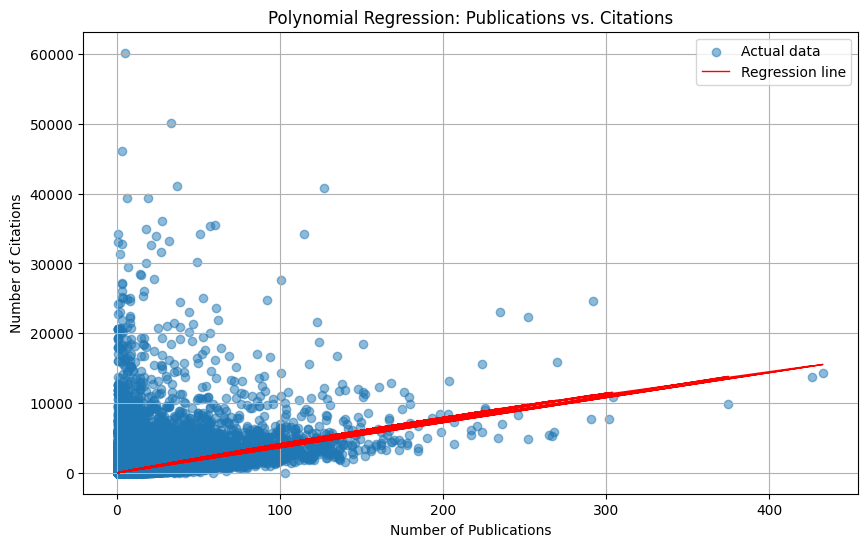

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
# Extract number of publications and total citations per author
# Split authors and explode to create a row for each author
authors_exploded = data.dropna(subset=['authors']).assign(
    authors=data['authors'].str.split(',')
).explode('authors')

# Group by author to get the count of publications and total citations
author_stats = authors_exploded.groupby('authors').agg(
    num_publications=('authors', 'count'),
    num_citations=('n_citation', 'sum')
).reset_index()

# Reshape data
X = author_stats['num_publications'].values.reshape(-1, 1)
y = author_stats['num_citations'].values


degree = 2  # You can adjust the degree
polynomial_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
polynomial_model.fit(X, y)
y_pred = polynomial_model.predict(X)
# Visualization
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.5, label="Actual data")
plt.plot(X, y_pred, color='red', linewidth=1, label="Regression line")
plt.title('Polynomial Regression: Publications vs. Citations')
plt.xlabel('Number of Publications')
plt.ylabel('Number of Citations')
plt.legend()
plt.grid(True)
plt.show()
